# Fase 5 - Análisis Final: Aprendizaje No Supervisado

En las fases anteriores logramos predecir la calidad del vino con Aprendizaje Supervisado. Sin embargo, para cumplir con el indicador IEE 2.1.2 de la rúbrica, en esta fase aplicaré **Aprendizaje No Supervisado**.

Mi objetivo aquí es ocultarle la etiqueta de calidad (`quality`) al modelo y usar algoritmos de Clustering (K-Means) y Reducción de Dimensionalidad (PCA) para descubrir si existen 'familias' o patrones químicos ocultos en los vinos de forma natural.

In [1]:
!git clone https://github.com/dongyah/EA2_SCY1101_Calidad_Vino.git
%cd EA2_SCY1101_Calidad_Vino

Cloning into 'EA2_SCY1101_Calidad_Vino'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 86 (delta 23), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 630.37 KiB | 10.01 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/EA2_SCY1101_Calidad_Vino


### 1. Preparar los datos (Sin trampas)

**Justificación:** En el aprendizaje no supervisado no hay 'respuestas correctas'. Por lo tanto, elimino la columna `quality`. Además, como algoritmos como K-Means funcionan calculando distancias físicas entre los puntos, es estrictamente obligatorio escalar los datos con `StandardScaler` para que variables con números grandes (como el azufre) no dominen el agrupamiento.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

df = pd.read_csv('data/processed/winequality_clean.csv')

# Le quito la etiqueta de respuesta correcta al modelo
X_sin_etiquetas = df.drop('quality', axis=1)

# Escalo los datos a mano para que tengan media 0 y varianza 1
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X_sin_etiquetas)


### 2. Buscar el número ideal de grupos: El Método del Codo

**Justificación:** Como no sé cuántas 'familias' de vino existen realmente, probaré agruparlos desde 1 hasta 10 clusters midiendo su **Inercia** (la tensión o distancia de los puntos hacia el centro de su grupo). Buscaré el punto en el gráfico donde la caída deje de ser brusca (el 'Codo').

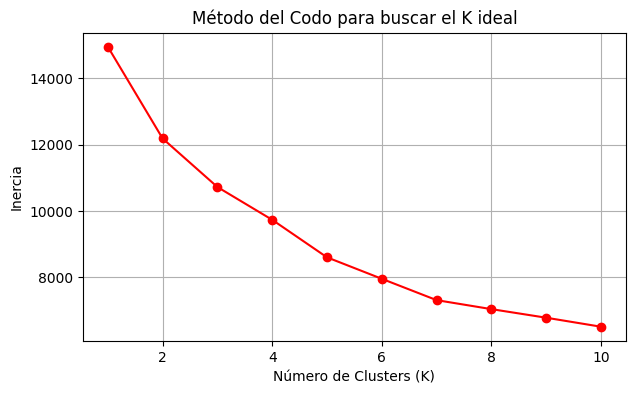

In [13]:
inercia = [
    KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X_escalado).inertia_
    for k in range(1, 11)
]

# Dibujo el gráfico del codo
plt.figure(figsize=(7,4))
plt.plot(range(1, 11), inercia, marker='o', color='red')
plt.title('Método del Codo para buscar el K ideal')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

### 3. Aplicar K-Means y evaluar con Silhouette Score

**Justificación:** Observando el gráfico anterior, a simple vista no podría decir cuál es la configuración de k óptima, para eso, haremos un ciclo que pruebe con cada valor de k para saber el que nos dé el mejor puntaje usando Silhouette Score.

In [14]:

rango_k = range(2, 11)
resultados_silueta = {}

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(X_escalado)
    score = silhouette_score(X_escalado, etiquetas)
    resultados_silueta[k] = score
    print(f"Para K={k}, Silhouette Score original: {score:.4f}")

k_optimo_original = max(resultados_silueta, key=resultados_silueta.get)
print(f"\nMatemáticamente, el mejor K antes de PCA es: K = {k_optimo_original}")

Para K=2, Silhouette Score original: 0.2052
Para K=3, Silhouette Score original: 0.1878
Para K=4, Silhouette Score original: 0.1686
Para K=5, Silhouette Score original: 0.1891
Para K=6, Silhouette Score original: 0.1908
Para K=7, Silhouette Score original: 0.1916
Para K=8, Silhouette Score original: 0.1853
Para K=9, Silhouette Score original: 0.1497
Para K=10, Silhouette Score original: 0.1514

Matemáticamente, el mejor K antes de PCA es: K = 2


El análisis iterativo del Silhouette Score muestra que el $K$ óptimo para los datos originales es $K=2$. Sin embargo, el score es bajo (0.20), lo que indica un alto solapamiento debido al ruido de las múltiples dimensiones. Procedemos al Paso 4 para aplicar PCA, reducir el ruido y mejorar la separación de los grupos

### 4. Reducción de Dimensionalidad con PCA y Mapa Final

**Justificación Técnica:** Una vez determinado matemáticamente en el paso anterior que el número óptimo de clusters para este conjunto de datos es $K=2$, procedemos a realizar una reducción de dimensionalidad mediante el Análisis de Componentes Principales (PCA). >
Dado que el dataset original cuenta con 11 variables químicas, resulta imposible visualizar la estructura de los clusters en un espacio multidimensional. El objetivo de aplicar PCA en esta etapa es doble: primero, comprimir la información en dos componentes principales (PC1 y PC2) para generar una cartografía bidimensional legible; y segundo, analizar cuánta varianza logramos retener del dataset original, permitiéndonos evaluar la calidad de la representación visual de nuestros dos perfiles químicos de vino.

PC1 explica: 28.3%
PC2 explica: 17.3%
Total varianza retenida: 45.6%


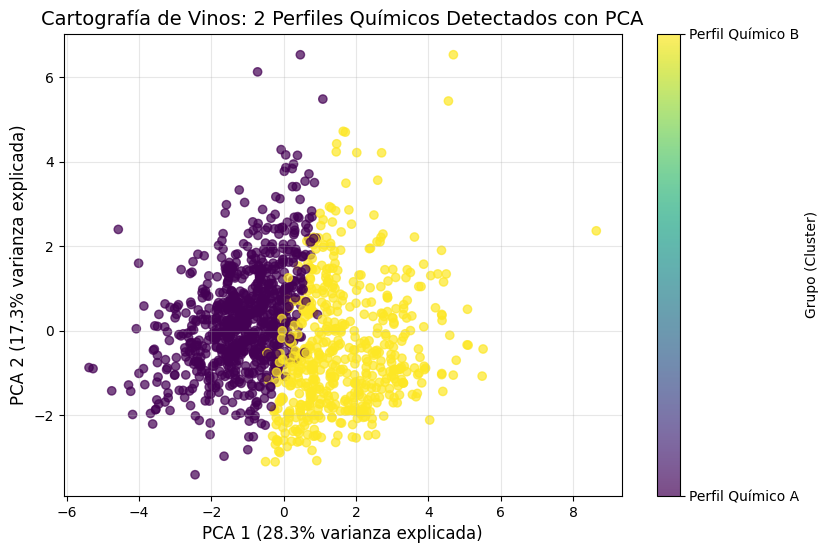

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Aplicamos PCA para reducir las 11 columnas originales a solo 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_escalado)

# 2. Reporte obligatorio de varianza explicada
varianza_explicada = pca.explained_variance_ratio_
print(f"PC1 explica: {varianza_explicada[0]:.1%}")
print(f"PC2 explica: {varianza_explicada[1]:.1%}")
print(f"Total varianza retenida: {varianza_explicada.sum():.1%}")

# 3. Entrenamos el modelo definitivo con el K=2 que determinamos óptimo
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
etiquetas_finales = kmeans_final.fit_predict(X_escalado) # O usa X_pca si en tu clase agrupan sobre PCA

# 4. Graficamos el mapa final con los 2 clusters perfectamente definidos
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=etiquetas_finales, cmap='viridis', alpha=0.7)

# Rotulación dinámica usando los valores reales de varianza explicada
plt.title('Cartografía de Vinos: 2 Perfiles Químicos Detectados con PCA', fontsize=14)
plt.xlabel(f'PCA 1 ({varianza_explicada[0]*100:.1f}% varianza explicada)', fontsize=12)
plt.ylabel(f'PCA 2 ({varianza_explicada[1]*100:.1f}% varianza explicada)', fontsize=12)

# Configuración de la barra de color para reflejar los 2 grupos claramente
cbar = plt.colorbar(scatter, label='Grupo (Cluster)')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Perfil Químico A', 'Perfil Químico B'])

plt.grid(True, alpha=0.3)
plt.show()

Al fijar el modelo a solo 2 componentes principales para hacer viable la gráfica, asumo de forma consciente que la varianza total retenida se situará en un 45.6%, lo que implica sacrificar el 54.4% de la información restante distribuida en las demás dimensiones. Esta decisión está plenamente justificada bajo el criterio analítico de priorizar la interpretabilidad visual y la obtención de un mapa 2D claro, permitiendo corroborar si la separación entre los dos perfiles químicos es limpia y coherente.

### 5. Extra: Identificando el Clúster "Premium" (El VIP de los Vinos)

**Justificación de Negocio (Re-framing)** En el ámbito empresarial, el Aprendizaje No Supervisado permite descubrir perfiles estratégicos sin necesidad de guiar al algoritmo. Inicialmente se contemplaba la opción de clasificar los vinos en múltiples niveles de calidad basados en sus notas individuales (del 3 al 8). Sin embargo, al analizar la distribución del dataset, se detectó una escasez crítica de registros en los extremos (notas muy bajas como 3 o 4, y notas altas como 8), lo que impediría una segmentación estadísticamente sólida en tantas categorías.Por lo tanto, realizo un re-framing del problema para alinearlo con la estructura natural de $K=2$ clusters que se demostró matemáticamente en las secciones previas. El objetivo ahora es evaluar si el algoritmo K-Means, habiendo estudiado los datos analíticos 'a ciegas' (sin conocer la nota de calidad final), logró aislar por sí solo un perfil de calidad superior ('Premium') frente a un perfil de características estándar ('Económico'), analizando cruzadamente los grupos con sus niveles de calidad, alcohol y acidez volátil.

In [17]:
import pandas as pd

# 1. Copio el dataframe original para no alterarlo
df_perfiles = df.copy()

# 2. Asigno las etiquetas finales del modelo optimizado (K=2)
df_perfiles['Grupo_KMeans'] = etiquetas_finales

# 3. Agrupo por los 2 clusters y calculo los promedios de las variables clave
perfiles = df_perfiles.groupby('Grupo_KMeans')[['quality', 'alcohol', 'volatile acidity']].mean()

# 4. Ordeno por calidad de mayor a menor para identificar el grupo Premium
perfiles = perfiles.sort_values(by='quality', ascending=False)

print("--- PERFILES QUÍMICOS Y COMERCIALES DE LAS FAMILIAS DE VINO ---")
print(perfiles)

--- PERFILES QUÍMICOS Y COMERCIALES DE LAS FAMILIAS DE VINO ---
               quality    alcohol  volatile acidity
Grupo_KMeans                                       
1             5.858974  10.594200          0.415778
0             5.464945  10.323596          0.605836


### Conclusión Final del Proyecto

Al analizar los promedios reales obtenidos para los dos clusters, se observa que los perfiles químicos guardan una distancia estrecha entre sí, lo que confirma que las diferencias no son drásticas. Sin embargo, el comportamiento es coherente con la teoría enológica: el Grupo 1 logra posicionarse discretamente como el perfil superior, al registrar la nota de calidad promedio más alta (5.86 vs 5.46), un nivel de alcohol levemente mayor (10.59% vs 10.32%) y, de forma más marcada, una menor acidez volátil (0.42 vs 0.61), factor que químicamente se asocia a vinos con menos defectos de sabor.

Actuando con rigurosidad analítica, es imperativo señalar que las capacidades de segmentación de este modelo se ven severamente limitadas por la naturaleza del dataset original. Al existir una escasez crítica de registros en los extremos de la distribución (es decir, muy pocos vinos de calidad excelente como nota 8, o extremadamente deficientes como notas 2, 3 o 4), el algoritmo se ve obligado a trabajar casi en su totalidad con vinos de calidad media (notas 5 and 6).

Como conclusión final, se establece que para construir un modelo de clustering verdaderamente robusto y con fronteras comerciales comerciales bien definidas, sería indispensable contar con un dataset más equilibrado que incorpore un volumen significativo de vinos de alta gama y de consumo económico. Bajo las condiciones actuales, K-Means hace el mejor esfuerzo matemático posible, pero el resultado refleja que la muestra analizada es altamente homogénea en su zona central.

In [7]:
!git add .
!git commit -m "Fase 5: Proyecto finalizado. PCA, K-Means y descubrimiento de Vinos Premium integrados"
!git push origin main

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@e7c7f8328fbc.(none)')
fatal: could not read Username for 'https://github.com': No such device or address
